# Exploratory Data Analysis

## Project Objective

Analyze global salary patterns in AI, machine learning, and data-related roles across experience levels, job titles, years, remote-work arrangements, company sizes, and geographical locations.

The analysis uses `salary_in_usd` to make salaries comparable across different currencies.

## Important Limitation

This dataset contains anonymously submitted salary records, not job postings. Therefore, record frequency represents dataset participation and should not be interpreted as labor-market demand.

## Analysis Questions

1. What does the overall salary distribution look like?
2. How do salaries differ across experience levels?
3. Which job titles are most represented in the dataset?
4. Which sufficiently represented job titles have the highest median salaries?
5. How have median salaries changed across years?
6. How do salaries differ between on-site, hybrid, and remote roles?
7. How do salaries differ across company sizes?
8. Which employee-residence countries are most represented?
9. Which sufficiently represented countries have the highest median salaries?
10. Which job titles experienced the highest salary growth between 2024 and 2025?

In [7]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
project_root = Path.cwd().parent

processed_file_path = (
    project_root / "data" / "processed" / "salaries_clean.csv"
)

df_analysis = pd.read_csv(processed_file_path)

df_analysis.shape

(151445, 15)

## 1. Overall Salary Distribution

This section examines how annual salaries are distributed and compares the mean with the median to understand the influence of unusually high salaries.

In [14]:
salary_mean = df_analysis["salary_in_usd"].mean()

salary_median = df_analysis["salary_in_usd"].median()

salary_mean, salary_median

(np.float64(157527.45841064412), 146100.0)

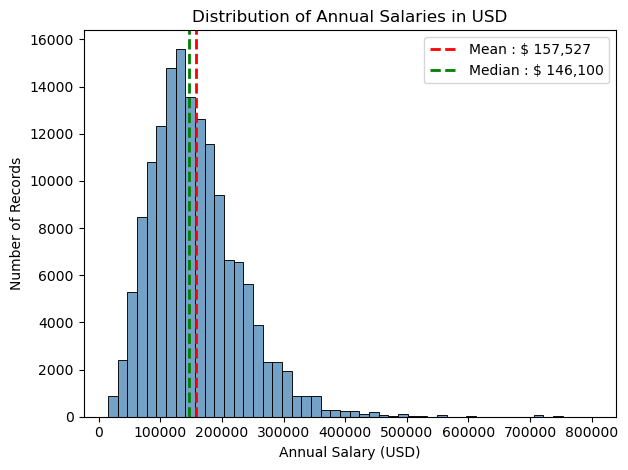

In [ ]:
plt.Figure(figsize=(10,6))

sns.histplot(
    data= df_analysis,
    x= "salary_in_usd",
    bins=50,
    color="steelblue"
)

plt.axvline(
    salary_mean,
    color= "red",
    linestyle= "--",
    linewidth=2,
    label=f"Mean : ${salary_mean: ,.0f}"
)

plt.axvline(
    salary_median,
    color="green",
    linestyle= "--",
    linewidth=2,
    label= f"Median : ${salary_median: ,.0f}"
)

plt.title("Distribution of Annual Salaries in USD")
plt.xlabel("Annual Salary (USD)")
plt.ylabel("Number of Records")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.legend()
plt.tight_layout()
plt.show()

### Insight

The salary distribution is right-skewed, with most salary records concentrated around the middle of the distribution and a relatively small number of extremely high salaries.

The mean annual salary is approximately $157,527, while the median is $146,100. The mean is about $11,427 higher than the median because high-salary records pull the average upward.

Therefore, the median is a more appropriate measure for describing a typical salary in this dataset.

### Salary Boxplot

A boxplot is used to summarize the salary distribution and visually identify statistically unusual salaries using the interquartile range.

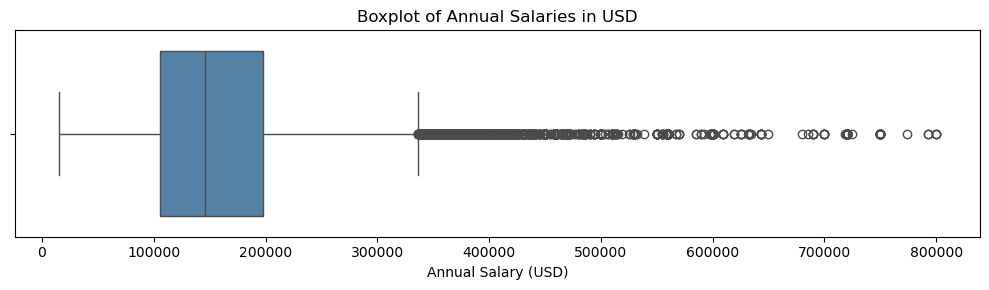

In [17]:
plt.figure(figsize=(10,3))

sns.boxplot(
    data=df_analysis,
    x="salary_in_usd",
    color="steelblue"
)

plt.title("Boxplot of Annual Salaries in USD")
plt.xlabel("Annual Salary (USD)")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()

### Boxplot Insight

The middle 50% of annual salaries lies between approximately $105,800 and $198,000, with a median salary of $146,100.

Salaries above approximately $336,300 are classified as statistical outliers using the IQR rule. These records were retained because they may represent valid high-paying roles rather than data errors.

The long upper tail confirms that the salary distribution is right-skewed.

## 2. Salary by Experience Level

This section examines how salary levels differ across entry-level, mid-level, senior-level, and executive-level roles.

In [18]:
experience_order = [
    "Entry-level",
    "Mid-level",
    "Senior-level",
    "Executive-level"
]

experience_salary_summary = (
    df_analysis.groupby("experience_level_label")
    .agg(
      record_count = ("salary_in_usd", "count"),
      median_salary = ("salary_in_usd", "median"),
      mean_salary = ("salary_in_usd", "mean")
    )
    .reindex(experience_order)
    .round(0)
)

experience_salary_summary

,record_count,median_salary,mean_salary
experience_level_label,,,
Entry-level,13663,86600.0,98962.0
Mid-level,46128,130000.0,142301.0
Senior-level,87491,161000.0,172658.0
Executive-level,4163,189370.0,200471.0


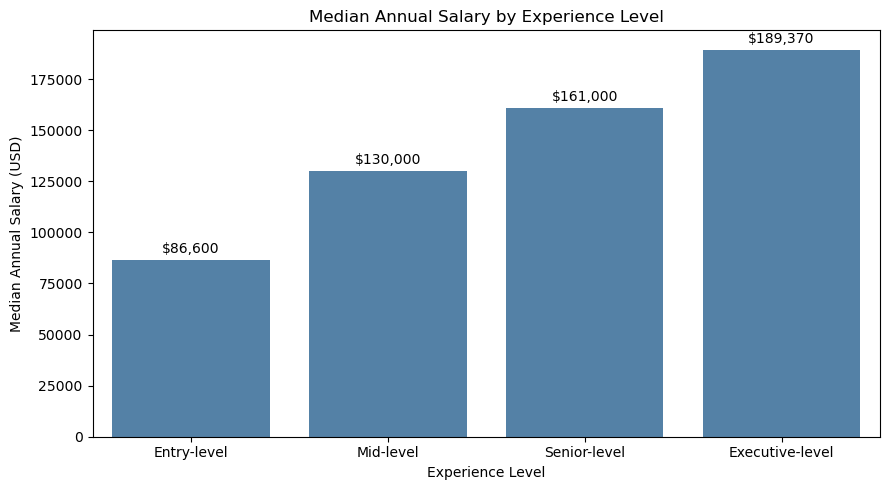

In [19]:
experience_plot_data = (
    experience_salary_summary.reset_index()
)

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data= experience_plot_data,
    x= "experience_level_label",
    y= "median_salary",
    color= "steelblue"
)

plt.title("Median Annual Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Median Annual Salary (USD)")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

ax.bar_label(
    ax.containers[0],
    labels=[
        f"${salary:,.0f}"
        for salary in experience_plot_data["median_salary"]
    ],
    padding=3
)

plt.tight_layout()
plt.show()

In [21]:
experience_growth = (
    experience_salary_summary[["median_salary"]].copy()
)

experience_growth["salary_differnce"] = (
    experience_growth["median_salary"].diff()
)

experience_growth["salary_increase_pct"] = (
    experience_growth["median_salary"].pct_change() * 100
)

experience_growth = experience_growth.round(1)

experience_growth

,median_salary,salary_differnce,salary_increase_pct
experience_level_label,,,
Entry-level,86600.0,NaN,NaN
Mid-level,130000.0,43400.0,50.1
Senior-level,161000.0,31000.0,23.8
Executive-level,189370.0,28370.0,17.6


### Experience-Level Salary Insights

Median annual salary increases consistently with experience level, rising from $86,600 for entry-level roles to $189,370 for executive-level roles.

The largest relative salary increase occurs between entry-level and mid-level positions, where the median salary rises by approximately 50.1%.

The median salary continues to increase at higher experience levels, but the relative increase becomes smaller: 23.8% from mid-level to senior-level and 17.6% from senior-level to executive-level.

Mean salaries are higher than median salaries across all experience levels, indicating that high-salary observations create right-skewed distributions within each group.

Senior-level records are the most represented in the dataset. However, record counts describe dataset representation and should not be interpreted as direct evidence of labor-market demand.